In [1]:

import networkx as nx
import numpy as np

In [ ]:

# Loading outputs of the repo https://github.com/Margento/GraphPoem-DHSI:

In [2]:

A_sem_subset_prev = np.load("margento_graphpoem_dhsi23_semantic_n_sonic_matrix_window_previous_to_singularity_3.npy", allow_pickle=True)
A_sem_subset = np.load("margento_graphpoem_dhsi23_adjacency_matrix_singularity_3_poems.npy", allow_pickle=True)
phon_feats_prev = np.load("margento_graphpoem_dhsi23_window_previous_to_singularity_3_phonological_feats.npy", allow_pickle=True)
phon_feats = np.load("margento_graphpoem_dhsi23_singularity_3_phonological_feats.npy", allow_pickle=True)
embs_prev = np.load("margento_graphpoem_dhsi23_embeddings_window_prev_to_singularity_3.npy", allow_pickle=True)
embs = np.load("margento_graphpoem_dhsi23_embeddings_singularity_3.npy", allow_pickle=True)

In [3]:

import numpy as np
import scipy.sparse as sp
import networkx as nx

def load_poem_adjacency(
    path,
    directed=False,
    threshold=None,
    remove_self_loops=True
):
    """
    Load a poem–poem adjacency matrix (already projected),
    safely handling NumPy-pickled sparse matrices.
    """

    A = np.load(path, allow_pickle=True)

    # 🔑 Unwrap object arrays (common with saved sparse matrices)
    if isinstance(A, np.ndarray) and A.dtype == object:
        if A.ndim == 0:
            A = A.item()
        elif len(A) == 1:
            A = A[0]

    # Ensure sparse
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    # Optional thresholding
    if threshold is not None:
        A = A.tocoo()
        mask = A.data >= threshold
        A = sp.coo_matrix(
            (A.data[mask], (A.row[mask], A.col[mask])),
            shape=A.shape
        ).tocsr()

    # Optional self-loop removal
    if remove_self_loops:
        A = A.tolil()
        A.setdiag(0.0)
        A = A.tocsr()
        A.eliminate_zeros()

    # Sanity check
    if A.shape[0] != A.shape[1]:
        raise ValueError(f"Poem adjacency must be square, got {A.shape}")

    G = nx.from_scipy_sparse_array(
        A,
        create_using=nx.DiGraph if directed else nx.Graph
    )

    return A, G


In [4]:

A_prev, G_prev = load_poem_adjacency(
    "margento_graphpoem_dhsi23_semantic_n_sonic_matrix_window_previous_to_singularity_3.npy",
    threshold=0.01
)

A_post, G_post = load_poem_adjacency(
    "margento_graphpoem_dhsi23_adjacency_matrix_singularity_3_poems.npy",
    threshold=0.01
)


In [5]:

import pickle

In [8]:



with open('margento_graphpoem_dhsi23_valid_poems_window_prev_to_singularity_3.pkl', 'rb') as f:
   valid_poems_prev_0 = pickle.load(f)


In [85]:
valid_poems_prev_0 == valid_poems_prev

True

In [6]:

with open('margento_graphpoem_dhsi23_valid_poems_singualrity_3.pkl', 'rb') as f1:
   valid_poems = pickle.load(f1)

In [87]:
len(valid_poems)

45

In [7]:

def annotate_poems(G, poem_list, target_poem):
    """
    Annotate graph nodes with poem metadata and
    mark the target poem ('That').
    """
    poem_to_idx = {p: i for i, p in enumerate(poem_list)}

    for i, p in enumerate(poem_list):
        G.nodes[i]["poem"] = p
        G.nodes[i]["is_that"] = (p == target_poem)

    if target_poem not in poem_to_idx:
        raise ValueError(f"Target poem '{target_poem}' not found in poem list")

    return poem_to_idx[target_poem]


In [8]:

import json

with open('margento_#graphpoem_dhsi23_windows_before_event3_descriptors.json', 'r', encoding='utf-8') as file:
    previous_descriptors = json.load(file)

with open("margento_#graphpoem_dhsi23_event_descriptors.json", 'r', encoding='utf-8') as file1:
    event_descriptors = json.load(file1)


In [9]:

event_i = 3   # third singularity
ev = event_descriptors[event_i-1]   # descriptor for event 3

In [10]:
POEM_FOLDER = "poems_#dhsi25"

In [11]:

import os

poems = sorted([f for f in os.listdir(POEM_FOLDER) if f.endswith(".txt")])

In [12]:

k_neigh = 1

prev_0_poems_selected = previous_descriptors[0].get(
    "poems_in_window_selected",
    previous_descriptors[0].get("poems_in_window", [])
)

indices = [poems.index(p) for p in prev_0_poems_selected if p in poems]

if not indices:
    indices = []
    for p in previous_descriptors[0].get("poems_in_window", []):
        if p in poems:
            indices.append(poems.index(p))

subset_idx = set()
for idx in indices:
    for j in range(max(0, idx-k_neigh), min(len(poems), idx+k_neigh+1)):
        subset_idx.add(j)

subset_idx = sorted(list(subset_idx))
poem_subset_prev = [poems[i] for i in subset_idx]

import os

valid_poems_prev = []
texts_prev = []

for p in poem_subset_prev:
    pth = os.path.join(POEM_FOLDER, p)
    if os.path.exists(pth):
        valid_poems_prev.append(p)


In [14]:
len(valid_poems_prev)

42

In [71]:
len(valid_poems_prev) == len(set(valid_poems_prev))

True

In [35]:
len(valid_poems_prev) == A_prev.shape[0]

True

In [95]:
len(valid_poems) == A_post.shape[0]

True

In [101]:
intersection_prev_n_event_valid = set(valid_poems).intersection(set(valid_poems_prev))

In [102]:
len(intersection_prev_n_event_valid)

9

In [103]:

poems_event_selected = ev.get("poems_in_window_selected", ev.get("poems_in_window", []))

In [104]:
intersection_prev_n_event_selected = set(prev_0_poems_selected).intersection(set(poems_event_selected))

In [105]:
len(intersection_prev_n_event_selected)

1

In [ ]:
# THAT VERY ONE POEM OUTPUTTED ABOVE IS... "THAT" (i.e., "Draft 65: That" by Rachel Blau DuPlessis

In [13]:


TARGET_POEM = 'place_rachel_blau_duplessis_draft_65_that_japanese_language_tao.txt'

that_idx_prev = annotate_poems(G_prev, valid_poems_prev, TARGET_POEM)
that_idx_post = annotate_poems(G_post, valid_poems, TARGET_POEM)

print("Index of 'That' in G_prev:", that_idx_prev)
print("Index of 'That' in G_post:", that_idx_post)

Index of 'That' in G_prev: 19
Index of 'That' in G_post: 13


In [14]:

import networkx as nx

def two_communities(G):
    # Louvain if available, fallback to greedy modularity
    try:
        import community as community_louvain
        part = community_louvain.best_partition(G, weight="weight")
    except Exception:
        comms = nx.algorithms.community.greedy_modularity_communities(
            G, weight="weight"
        )
        part = {}
        for i, c in enumerate(comms):
            for n in c:
                part[n] = i
    return part


In [15]:

part_prev = two_communities(G_prev)
part_post = two_communities(G_post)


In [22]:

# how many nodes per community?
from collections import Counter

print("Prev:", Counter(part_prev.values()))
print("Post:", Counter(part_post.values()))


Prev: Counter({0: 18, 1: 14, 2: 10})
Post: Counter({0: 20, 1: 16, 2: 9})


In [100]:

that_prev = 19
that_post = 13

print("That – prev community:", part_prev[that_prev])
print("That – post community:", part_post[that_post])


That – prev community: 1
That – post community: 1


In [16]:

def annotate_graph_with_communities(G, part):
    for n in G.nodes:
        G.nodes[n]["community"] = part.get(n, -1)
    return G

G_prev = annotate_graph_with_communities(G_prev, part_prev)
G_post = annotate_graph_with_communities(G_post, part_post)


In [109]:

G_prev.nodes[19]

{'poem': 'place_rachel_blau_duplessis_draft_65_that_japanese_language_tao.txt',
 'is_that': True,
 'community': 1}

In [110]:
G_post.nodes[13]

{'poem': 'place_rachel_blau_duplessis_draft_65_that_japanese_language_tao.txt',
 'is_that': True,
 'community': 1}

In [24]:


def edge_weight_stats_by_community(G):
    """
    Returns mean, std, count of edge weights
    grouped by (community_u, community_v)
    """
    buckets = defaultdict(list)

    for u, v, d in G.edges(data=True):
        cu = G.nodes[u].get("community", -1)
        cv = G.nodes[v].get("community", -1)
        w  = d.get("weight", 1.0)
        key = tuple(sorted((cu, cv)))
        buckets[key].append(w)
        # buckets[(cu, cv)].append(w)

    stats = {}
    for k, vals in buckets.items():
        vals = np.array(vals, dtype=float)
        stats[k] = {
            "count": len(vals),
            "mean": float(vals.mean()),
            "std":  float(vals.std())
        }
    return stats


In [ ]:

stats_prev = edge_weight_stats_by_community(G_prev)
stats_post = edge_weight_stats_by_community(G_post)


In [118]:

stats_prev

{(2, 0): {'count': 6, 'mean': 0.33158943566255705, 'std': 0.06374899161137872},
 (2, 2): {'count': 27,
  'mean': 0.29601206091032434,
  'std': 0.10736222190955624},
 (2, 1): {'count': 12,
  'mean': 0.23671875811922036,
  'std': 0.06723953042058135},
 (1, 1): {'count': 64,
  'mean': 0.44640382064337414,
  'std': 0.09657208308517329},
 (1, 0): {'count': 6, 'mean': 0.47591656887935524, 'std': 0.0794591729333171},
 (1, 2): {'count': 8, 'mean': 0.20975035611329662, 'std': 0.0980176554385497},
 (0, 0): {'count': 88, 'mean': 0.5136756777795726, 'std': 0.07205072954653596},
 (0, 1): {'count': 3, 'mean': 0.44170993081319315, 'std': 0.08908538498127104},
 (0, 2): {'count': 5, 'mean': 0.31059695202999793, 'std': 0.08906945923289764}}

In [119]:

stats_post

{(0, 0): {'count': 104,
  'mean': 0.46341016815695046,
  'std': 0.15058902983704386},
 (2, 2): {'count': 32, 'mean': 0.2963446143667393, 'std': 0.10686375801564482},
 (2, 1): {'count': 3, 'mean': 0.3062651001461943, 'std': 0.03828395047604969},
 (1, 1): {'count': 83, 'mean': 0.4831153272822456, 'std': 0.09290297299491682},
 (1, 2): {'count': 7, 'mean': 0.23555653838525709, 'std': 0.07491214786177353},
 (1, 0): {'count': 5, 'mean': 0.4749723124842564, 'std': 0.026589516404581966},
 (2, 0): {'count': 1, 'mean': 0.07415709957663319, 'std': 0.0}}

In [26]:


from collections import defaultdict

def degree_stats_by_community(G):
    """
    Returns degree list and summary stats per community
    """
    degs = defaultdict(list)

    for n in G.nodes:
        c = G.nodes[n].get("community", -1)
        degs[c].append(G.degree(n, weight="weight"))

    stats = {}
    for c, vals in degs.items():
        vals = np.array(vals, dtype=float)
        stats[c] = {
            "count": len(vals),
            "mean_degree": float(vals.mean()),
            "std_degree": float(vals.std()),
            "max_degree": float(vals.max())
        }
    return stats

deg_prev = degree_stats_by_community(G_prev)
deg_post = degree_stats_by_community(G_post)


In [116]:

deg_prev

{2: {'count': 10,
  'mean_degree': 2.4045800609619863,
  'std_degree': 0.4302750349298032,
  'max_degree': 3.1935604452008657},
 1: {'count': 14,
  'mean_degree': 4.702781871028901,
  'std_degree': 1.1725699886567418,
  'max_degree': 6.363035957099992},
 0: {'count': 18,
  'mean_degree': 5.451670548280323,
  'std_degree': 1.1593246589945496,
  'max_degree': 7.294982367407177}}

In [117]:
deg_post

{0: {'count': 20,
  'mean_degree': 4.941916681932182,
  'std_degree': 1.3751111473640787,
  'max_degree': 8.222730721885888},
 2: {'count': 9,
  'mean_degree': 2.4008781653537037,
  'std_degree': 0.2681624480938607,
  'max_degree': 2.75036611501584},
 1: {'count': 16,
  'mean_degree': 5.321231060025591,
  'std_degree': 1.4811915441330403,
  'max_degree': 7.564293602814958}}

In [ ]:
| graph metric   | sound parameter       |
| -------------- | --------------------- |
| within mean    | harmonicity           |
| within std     | detuning spread       |
| degree mean    | amplitude / activity  |
| degree std     | rhythmic irregularity |
| cross mean     | signal bleed          |
| cross collapse | gating event          |
| community size | ensemble density      |

In [120]:


# --------------------------------------------------
# Helpers
# --------------------------------------------------

def safe_mean(x, default=0.0):
    if x is None:
        return default
    return float(x)

def normalize(x, lo, hi):
    """Normalize x into 0–1 range with clipping"""
    if hi - lo == 0:
        return 0.0
    return float(np.clip((x - lo) / (hi - lo), 0.0, 1.0))


# --------------------------------------------------
# Extract within-community stats
# --------------------------------------------------

def extract_within_stats(edge_stats, community):
    """
    edge_stats keys are tuples like (c1, c2)
    """
    key = (community, community)
    if key not in edge_stats:
        return {"mean": 0.0, "std": 0.0, "count": 0}
    return edge_stats[key]


# --------------------------------------------------
# Extract cross-community stats
# --------------------------------------------------

def build_permeability_matrix(edge_stats, communities):
    """
    Mean edge weight between communities → signal transfer gain
    """
    mat = {}

    for c1 in communities:
        mat[c1] = {}
        for c2 in communities:
            key = (c1, c2)
            if key in edge_stats:
                mat[c1][c2] = edge_stats[key]["mean"]
            else:
                mat[c1][c2] = 0.0

    return mat


# --------------------------------------------------
# Core mapping: graph → sound
# --------------------------------------------------

def community_sound_parameters(edge_stats, degree_stats):
    """
    Convert graph stats into sonic control parameters.
    """

    communities = sorted(degree_stats.keys())
    params = {}

    # global ranges for normalization
    within_means = [extract_within_stats(edge_stats, c)["mean"] for c in communities]
    within_stds  = [extract_within_stats(edge_stats, c)["std"]  for c in communities]
    degree_means = [degree_stats[c]["mean_degree"] for c in communities]
    degree_stds  = [degree_stats[c]["std_degree"]  for c in communities]

    for c in communities:

        within = extract_within_stats(edge_stats, c)

        cohesion = within["mean"]
        instability = within["std"]
        degree_mean = degree_stats[c]["mean_degree"]
        degree_std  = degree_stats[c]["std_degree"]

        params[c] = {

            # harmonic clarity
            "harmonicity":
                normalize(cohesion, min(within_means), max(within_means)),

            # pitch drift / spectral spread
            "detune_amount":
                normalize(instability, min(within_stds), max(within_stds)),

            # activity / loudness / density
            "activity_level":
                normalize(degree_mean, min(degree_means), max(degree_means)),

            # rhythmic irregularity
            "rhythmic_variability":
                normalize(degree_std, min(degree_stds), max(degree_stds)),

            # community size (ensemble density proxy)
            "ensemble_size":
                degree_stats[c]["count"]
        }

    # cross-community signal bleed
    permeability = build_permeability_matrix(edge_stats, communities)

    return {
        "community_params": params,
        "permeability": permeability
    }


# --------------------------------------------------
# Identify structural regime per community
# --------------------------------------------------

def classify_community_regime(prev_params, post_params):
    """
    Detect structural change type.
    """

    regime = {}

    for c in prev_params:

        coh_prev = prev_params[c]["harmonicity"]
        coh_post = post_params[c]["harmonicity"]

        det_prev = prev_params[c]["detune_amount"]
        det_post = post_params[c]["detune_amount"]

        if coh_post > coh_prev and det_post < det_prev:
            regime[c] = "condensing"

        elif coh_post < coh_prev and det_post > det_prev:
            regime[c] = "destabilising"

        else:
            regime[c] = "stable"

    return regime


# --------------------------------------------------
# Invariant voice definition for “That”
# --------------------------------------------------

def that_voice_profile(base_pitch=220.0):
    """
    Timbral identity that persists across topology.
    Context will modulate, but this stays constant.
    """

    return {
        "core_frequency": base_pitch,
        "formant_ratio": 1.618,      # golden resonance marker
        "spectral_centroid": 0.45,   # stable identity brightness
        "vibrato_rate": 0.18,
        "vibrato_depth": 0.02
    }


# --------------------------------------------------
# MASTER BUILD FUNCTION
# --------------------------------------------------

def build_sonic_world(prev_edge_stats,
                      post_edge_stats,
                      prev_degree_stats,
                      post_degree_stats,
                      that_prev_comm,
                      that_post_comm):

    prev_world = community_sound_parameters(prev_edge_stats, prev_degree_stats)
    post_world = community_sound_parameters(post_edge_stats, post_degree_stats)

    regimes = classify_community_regime(
        prev_world["community_params"],
        post_world["community_params"]
    )

    that_voice = that_voice_profile()

    return {
        "prev": prev_world,
        "post": post_world,
        "regimes": regimes,
        "that_voice": that_voice,
        "that_location": {
            "prev": that_prev_comm,
            "post": that_post_comm
        }
    }


In [158]:

sonic_world = build_sonic_world(
    stats_prev,
    stats_post,
    deg_prev,
    deg_post,
    that_prev_comm=1,
    that_post_comm=1
)

In [ ]:

| Community behaviour   | Sound model                            |
| --------------------- | -------------------------------------- |
| dense / high degree   | resonant body (string plate, membrane) |
| sparse                | breath / noise                         |
| bridge community      | harmonic shimmer / inharmonic partials |
| structurally unstable | granular fragmentation                 |


In [238]:

# first, utilities

SR = 48000  # sample rate


def normalize_audio(audio, eps=1e-9):
    audio = np.asarray(audio, dtype=float)

    # remove NaNs and Infs first
    audio = np.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0)

    peak = np.max(np.abs(audio))

    # if signal collapsed, don't divide
    if peak < eps:
        return audio

    return audio / peak


def envelope(length, attack=0.01, release=0.1):
    n = int(length)
    a = int(attack * SR)
    r = int(release * SR)

    env = np.ones(n)
    if a > 0:
        env[:a] = np.linspace(0, 1, a)
    if r > 0:
        env[-r:] = np.linspace(1, 0, r)
    return env


# Continuous structural transformation.
def morph_worlds(sig_prev, sig_post, alpha):
    L = min(len(sig_prev), len(sig_post))
    return (1-alpha)*sig_prev[:L] + alpha*sig_post[:L]


# FULL COMMUNITY SOUNDSCAPE
def synthesize_world(deg_stats, that_comm, duration=2.0):
    layers = []

    for comm in sorted(deg_stats.keys()):
        voice = community_voice(comm, deg_stats, duration)

        # stronger influence if this is "That" community
        if comm == that_comm:
            voice = apply_that_field(voice, strength=0.7)

        layers.append(voice)

    mix = sum(layers)
    return normalize_audio(mix)


In [241]:

# more partials, inharmonic stretch, moving brightness, internal beating
# def resonant_body(freq, duration, brightness=0.4, detune=0.02, motion=0.2):
# more partials, inharmonic stretch, slow motion


# textured air, not thin noise

def breath_noise(duration, color=0.6, layers=5):
    n = int(duration * SR)
    t = np.arange(n)/SR
    out = np.zeros(n)

    for i in range(layers):
        noise = np.random.randn(n)
        fft = np.fft.rfft(noise)
        freqs = np.linspace(1, len(fft), len(fft))
        fft /= freqs ** (color + 0.1*np.sin(2*np.pi*(0.03+i*0.02)*t[:len(freqs)]))
        shaped = np.fft.irfft(fft, n=n)
        shaped *= 0.6 + 0.4*np.sin(2*np.pi*(0.04+i*0.01)*t)
        out += shaped

    return out * envelope(n, 0.05, 0.6)

# swarming, not sparse
# def granular_shimmer(freq, duration, density=80, spread=0.2):
def granular_shimmer(freq, duration, density=99, spread=0.01):
    """
    freq      -> base frequency of grains
    duration  -> seconds
    density   -> grains per second → higher=dense, thicker sound
    spread    -> frequency deviation per grain → small for more compact rumble
    """
    n = int(duration * SR)
    out = np.zeros(n)
    # grain_len = int(0.07 * SR)  # ~70ms → short percussive grains
    grain_len = int(0.1 * SR)
    
    for _ in range(int(duration*density)):
        start = np.random.randint(0, n - grain_len)
        t = np.arange(grain_len)/SR
        f = freq * (1 + np.random.uniform(-spread, spread))
        grain = np.sin(2*np.pi*f*t)

        # internal FM ripple → subtle texture, adds “drumish” complexity
        # grain *= np.sin(2*np.pi*(2 + np.random.rand()*6)*t)
        grain *= np.hanning(grain_len)
        out[start:start+grain_len] += grain

    return out * 0.85


In [132]:

audio_2 = perform_transition(
    deg_prev,
    deg_post,
    that_prev_comm=1,
    that_post_comm=1,
    steps_pre=8,
    steps_post=8,
    duration=3.0
)

write("margento_#graphpoem_dhsi23_singularity_transition_2.wav", SR, (audio_2 * 0.99).astype(np.float32))

In [242]:

def derive_structure_fields(edge_stats):
    intra = []
    inter = []
    variability = []

    for (c1, c2), s in edge_stats.items():
        if c1 == c2:
            intra.append(s["mean"])
            variability.append(s["std"])
        else:
            inter.append(s["mean"])

    return {
        "cohesion": np.mean(intra) if intra else 0,
        "coupling": np.mean(inter) if inter else 0,
        "turbulence": np.mean(variability) if variability else 0
    }

fields_prev = derive_structure_fields(stats_prev)
fields_post = derive_structure_fields(stats_post)


def synth_world_pre(deg_stats, structure, that_comm, duration):
    voices = []

    for c in deg_stats:
        v = community_voice(c, deg_stats, duration)

        # cohesion = harmonic stability
        v *= (0.8 + 0.4 * structure["cohesion"])

        voices.append(v)

    world = sum(voices)

    # inter-community coupling = mild cross modulation
    world *= 1 + 0.2 * structure["coupling"]

    world = apply_that_field(world, strength=0.5)

    return world


def synth_world_post(deg_stats, structure, that_comm, duration):
    voices = []

    for c in deg_stats:
        v = community_voice(c, deg_stats, duration)

        # turbulence breaks harmonicity
        jitter = 1 + structure["turbulence"] * np.random.randn(len(v)) * 0.02
        v *= jitter

        # weakened internal cohesion
        v *= (0.6 + 0.2 * structure["cohesion"])

        voices.append(v)

    world = sum(voices)

    # strong cross-community coupling → amplitude beating
    beat = 1 + 0.6 * structure["coupling"] * np.sin(2*np.pi*0.4*np.arange(len(world))/SR)
    world *= beat

    # stronger That gravitational dominance
    world = apply_that_field(world, strength=0.85, drift=0.015)

    return world


def inject_memory(world, sonic_world, amount=0.2, phase="prev"):
    world = np.asarray(world, dtype=float)

    if sonic_world is None:
        return world

    if not isinstance(sonic_world, dict):
        raise TypeError(f"sonic_world must be dict, got {type(sonic_world)}")

    if phase not in sonic_world:
        raise KeyError(f"phase='{phase}' not found in sonic_world keys {sonic_world.keys()}")

    # If dict contains 'audio', use it; otherwise try to use the dict directly
    if isinstance(sonic_world[phase], dict) and "audio" in sonic_world[phase]:
        sonic_array = np.asarray(sonic_world[phase]["audio"], dtype=float)
    else:
        # assume the dict itself is already an audio array
        try:
            sonic_array = np.asarray(sonic_world[phase], dtype=float)
        except:
            raise TypeError(f"Cannot convert sonic_world[{phase}] to array")

    n = min(len(world), len(sonic_array))
    world[:n] += amount * sonic_array[:n]

    return world

# pre world → low memory weight
# post world → higher memory weight but spectrally blurred


In [243]:


import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# ----------------------------------------------------------
# MAP EIGENVALUES → AUDIO FREQUENCIES
# ----------------------------------------------------------

def eigen_to_freqs(eigvals, fmin=40, fmax=4000):
    """
    Log mapping gives perceptual balance.
    """
    ev = np.maximum(eigvals, 1e-9)
    spread = np.ptp(ev)
    if spread < 1e-6:
        ev = np.linspace(0,1,len(ev))
    else:
        ev = (ev - ev.min()) / spread
    return fmin * (fmax / fmin) ** ev


# ----------------------------------------------------------
# MODE AMPLITUDES FROM EIGENVECTORS
# ----------------------------------------------------------

def mode_amplitudes(eigvecs, power=1.3):
    amps = np.linalg.norm(eigvecs, axis=0)
    amps /= amps.max() + 1e-12
    return amps ** power


# ----------------------------------------------------------
# MODAL RESONATOR
# ----------------------------------------------------------

def modal_resonator(freq, duration, decay=2.0):
    t = np.arange(int(duration * SR)) / SR
    return np.sin(2*np.pi*freq*t) * np.exp(-t * decay)


def graph_filter_bank(freqs, amps, duration):
    out = np.zeros(int(duration * SR))
    maxf = max(freqs)

    for f, a in zip(freqs, amps):
        decay = 1.0 + 4.0 * (f / maxf)
        out += a * modal_resonator(f, duration, decay)

    return out


# ----------------------------------------------------------
# PURE GRAPH RESONANCE
# ----------------------------------------------------------

def topology_resonance(A, duration=4.0, n_modes=32):
    eigvals, eigvecs = graph_modes(A, n_modes)
    freqs = eigen_to_freqs(eigvals)
    amps = mode_amplitudes(eigvecs)
    return graph_filter_bank(freqs, amps, duration)


# ----------------------------------------------------------
# EXCITED TOPOLOGY
# ----------------------------------------------------------

def excite_topology(A, excitation, duration=4.0, n_modes=32):
    body = topology_resonance(A, duration, n_modes)

    n = min(len(body), len(excitation))
    out = np.zeros_like(body)
    out[:n] = body[:n] * excitation[:n]

    return out


# ----------------------------------------------------------
# PRE / POST TOPOLOGY LAYERS
# ----------------------------------------------------------

def topology_layer_pre(A, duration=4.0):
    exc = breath_noise(duration, layers=6)
    return excite_topology(A, exc, duration)


def topology_layer_post(A, duration=4.0):
    exc = event_shock(duration, intensity=1.4)
    return excite_topology(A, exc, duration)


In [244]:

# Make sure sonic_world has audio arrays for memory injection
def ensure_sonic_audio(sonic_world, deg_prev, deg_post, stats_prev, stats_post, that_prev_comm, that_post_comm, duration=3.0):
    if "audio" not in sonic_world["prev"]:
        fields_prev = derive_structure_fields(stats_prev)
        sonic_world["prev"]["audio"] = synth_world_pre(
            deg_prev, fields_prev, that_prev_comm, duration
        )

    if "audio" not in sonic_world["post"]:
        fields_post = derive_structure_fields(stats_post)
        sonic_world["post"]["audio"] = synth_world_post(
            deg_post, fields_post, that_post_comm, duration
        )
    return sonic_world


In [187]:


def perform_transition(
    deg_prev,
    deg_post,
    stats_prev,
    stats_post,
    that_prev_comm,
    that_post_comm,
    sonic_world=None,
    duration=3.0
):
    """
    Build transition audio incorporating pre-event, event, and post-event worlds.
    Integrates:
    - community degree stats (prev/post)
    - structure fields (Option B)
    - previous sonic memory
    - topology-based resonance filter
    """

    # --- derive structure fields from stats ---
    fields_prev = derive_structure_fields(stats_prev)
    fields_post = derive_structure_fields(stats_post)

    frames = []

    # --- PRE-event buildup ---
    for _ in range(5):
        w = synth_world_pre(deg_prev, fields_prev, that_prev_comm, duration)
        w = inject_memory(w, sonic_world, 0.2, phase="prev")

        # topology resonance of previous graph
        top_prev = topology_layer_pre(A_prev, duration)
        w += 0.5 * top_prev  # mix in resonance
        frames.append(w)

    # --- EVENT ---
    frames.append(event_shock(2.0))

    # --- POST-event (new physics) ---
    for _ in range(6):
        w = synth_world_post(deg_post, fields_post, that_post_comm, duration)

        # memory returns but transformed
        w = inject_memory(w, sonic_world, 0.5, phase="post")

        # topology resonance of post-event graph
        top_post = topology_layer_post(A_post, duration)
        w += 0.7 * top_post
        frames.append(w)

    # --- final normalization ---
    return normalize_audio(np.concatenate(frames))


In [168]:

sonic_world = ensure_sonic_audio(
    sonic_world, deg_prev, deg_post, stats_prev, stats_post, 
    that_prev_comm=1, that_post_comm=1, duration=3.0
)

In [245]:


# SUBTERRANEAN SONIC PRESET


SUB_BASS_CUTOFF = 160       # global spectral ceiling
ULTRA_LOW = 28              # infrasonic reinforcement
CAVITY_RESONANCE = 55       # drum body Hz


# -----------------------------------------
# MASTER CAVITY FILTER (CRITICAL)
# -----------------------------------------
def cavern_filter(audio, cutoff=SUB_BASS_CUTOFF, resonance=CAVITY_RESONANCE):
    n = len(audio)

    fft = np.fft.rfft(audio)
    freqs = np.fft.rfftfreq(n, 1/SR)

    # strong low-pass
    fft[freqs > cutoff] *= 0.03

    # cavity resonance peak
    peak = np.exp(-((freqs - resonance)**2) / (2 * 8**2))
    fft *= (1 + 1.8 * peak)

    return np.fft.irfft(fft, n)


def resonant_body(freq, duration, brightness=0.28, detune=0.012, motion=0.04):
    t = np.arange(int(duration * SR)) / SR
    signal = np.zeros_like(t)

    partials = 22

    for k in range(1, partials + 1):
        stretch = 1 + 0.008 * k
        f = freq * k * stretch

        # slow structural drift
        f *= 1 + detune * np.sin(2*np.pi*(0.03 + 0.004*k)*t)

        amp = np.exp(-brightness * k)
        signal += amp * np.sin(2*np.pi*f*t)

    # tectonic breathing (VERY slow)
    signal *= 0.8 + 0.2*np.sin(2*np.pi*motion*t)

    # infrasonic reinforcement
    sub = np.sin(2*np.pi*ULTRA_LOW*t) * 0.35

    return (signal + sub) * envelope(len(signal), 0.02, 0.95)


def pressure_field(duration, density=5):
    n = int(duration * SR)
    t = np.arange(n)/SR

    out = np.zeros(n)

    for _ in range(density):
        noise = np.random.randn(n)

        fft = np.fft.rfft(noise)
        freqs = np.linspace(1, len(fft), len(fft))

        # extremely dark spectrum
        fft /= freqs ** 2.2

        shaped = np.fft.irfft(fft, n=n)

        # ultra slow swelling
        shaped *= 0.7 + 0.3*np.sin(2*np.pi*0.02*t)

        out += shaped

    return out * envelope(n, 0.2, 0.95)


def tectonic_pulse(freq, duration):
    t = np.arange(int(duration * SR))/SR

    carrier = np.sin(2*np.pi*freq*t)
    decay = np.exp(-4*t)

    body = carrier * decay

    # secondary cavity ring
    body += 0.5*np.sin(2*np.pi*(freq*0.6)*t) * np.exp(-2.5*t)

    return body


def match_length_pad(*signals):
    """
    Pad shorter signals with zeros to longest length.
    """
    max_len = max(len(s) for s in signals)
    out = []
    for s in signals:
        if len(s) < max_len:
            pad = np.zeros(max_len - len(s))
            s = np.concatenate([s, pad])
        out.append(s)
    return out


def community_voice(comm_id, degree_stats, duration=3.0):
    d = degree_stats[comm_id]

    density = d["mean_degree"]
    variability = d["std_degree"]

    base = 42 + 18 * comm_id

    mass = resonant_body(
        base,
        duration,
        brightness=0.25 + variability*0.05,
        motion=0.03 + variability*0.01
    )

    pressure = pressure_field(duration, density=3 + int(density))

    impact = tectonic_pulse(base*0.7, duration*0.6)

    mass, pressure, impact = match_length_pad(mass, pressure, impact)
    
    return 2.6*mass + 1.2*pressure + 1.5*impact



def apply_that_field(audio, strength=0.85, drift=0.004):
    n = len(audio)
    t = np.arange(n)/SR

    warp = 1 + drift*np.sin(2*np.pi*0.02*t)
    phase = np.cumsum(warp)

    warped = np.interp(phase/phase.max()*(n-1), np.arange(n), audio)

    gravity = 1 - strength*np.exp(-((t-t.mean())**2)/0.25)

    return warped * gravity


def event_shock(duration=4.0, intensity=2.4):
    n = int(duration * SR)
    t = np.arange(n)/SR

    noise = np.random.randn(n)

    fft = np.fft.rfft(noise)
    freqs = np.linspace(0,1,len(fft))

    # energy concentrated low
    fft *= np.exp(-freqs*6)

    burst = np.fft.irfft(fft, n=n)

    env = np.exp(-2.2*t) * np.sin(np.pi*t/duration)**2

    subboom = np.sin(2*np.pi*36*t) * np.exp(-3*t)

    return intensity * (burst + subboom) * env


In [246]:

def post_event_physics(audio):
    """
    Makes post-event world feel structurally altered.
    Applies dispersion, spectral tilt, and temporal instability.
    """

    n = len(audio)
    t = np.arange(n) / SR

    # --- 1. frequency dispersion (partials drift apart)
    phase = np.cumsum(1 + 0.002*np.sin(2*np.pi*0.3*t)
                        + 0.001*np.sin(2*np.pi*1.7*t))
    dispersed = np.interp(
        phase / phase.max() * (n-1),
        np.arange(n),
        audio
    )

    # --- 2. spectral thinning (energy moves upward)
    fft = np.fft.rfft(dispersed)
    freqs = np.linspace(0, 1, len(fft))
    fft *= (0.7 + 0.6*freqs**1.2)
    dispersed = np.fft.irfft(fft, n=n)

    # --- 3. structural tremor (micro-instability)
    tremor = 1 + 0.04*np.sin(2*np.pi*5*t)
    dispersed *= tremor

    return dispersed


def apply_that_post(audio, strength=0.6, drift=0.02):
    n = len(audio)
    t = np.arange(n) / SR

    # unstable temporal field
    warp = 1 + drift*np.sin(2*np.pi*0.07*t) + 0.006*np.sin(2*np.pi*0.9*t)
    phase = np.cumsum(warp)
    warped = np.interp(phase/phase.max()*(n-1), np.arange(n), audio)

    # weaker gravitational center (spread out)
    gravity = 1 - strength*np.exp(-((t - t.mean())**2)/0.35)

    # slight spectral diffusion
    kernel = int(0.015 * SR)
    blur = np.convolve(warped, np.ones(kernel)/kernel, mode="same")

    return 0.55*warped + 0.45*blur


def spectral_lift(audio, amount=0.3):
    """
    Gradually shifts spectral energy upward.
    amount: 0–1 (0 = no lift, 1 = strong lift)
    """

    n = len(audio)
    fft = np.fft.rfft(audio)
    freqs = np.fft.rfftfreq(n, 1 / SR)

    nyquist = freqs.max()

    # smooth rising tilt
    lift_curve = (freqs / nyquist) ** (0.6 + 1.8 * amount)

    # preserve low frequencies, boost highs
    gain = 1 + amount * lift_curve

    fft *= gain

    return np.fft.irfft(fft, n)


In [247]:

def split_low_high(audio, split_hz=120):
    n = len(audio)
    fft = np.fft.rfft(audio)
    freqs = np.fft.rfftfreq(n, 1 / SR)

    low_fft = fft.copy()
    high_fft = fft.copy()

    low_fft[freqs > split_hz] = 0
    high_fft[freqs <= split_hz] = 0

    low = np.fft.irfft(low_fft, n)
    high = np.fft.irfft(high_fft, n)

    return low, high


def reinforce_sub(audio, drive=1.5):
    return np.tanh(drive * audio)


In [253]:

def match_rms(reference, target, strength=1.0):
    ref_rms = np.sqrt(np.mean(reference**2) + 1e-12)
    tgt_rms = np.sqrt(np.mean(target**2) + 1e-12)

    gain = (ref_rms / tgt_rms) ** strength
    return target * gain

def micro_saturation(x, drive=1.4):
    return np.tanh(drive * x)

In [274]:
def safe_norm(x, target=0.9):
    x = np.nan_to_num(x)
    peak = np.max(np.abs(x)) + 1e-9
    return target * x / peak

In [ ]:

# DYNAMICS 


In [282]:

def topology_time_profile(A, duration):
    """
    Creates a slow structural envelope derived from Laplacian spectrum.
    """
    eigvals, _ = graph_modes(A, k=min(16, A.shape[0]-1))

    # algebraic connectivity (Fiedler value)
    fiedler = sorted(eigvals)[1] if len(eigvals) > 1 else 0.001

    # instability measure (spectral spread)
    spread = np.std(eigvals)

    t = np.linspace(0, duration, int(duration*SR))

    # stable networks oscillate slowly
    slow_rate = 0.02 + 0.15 * fiedler

    # unstable networks fluctuate
    fast_rate = 0.1 + 0.6 * spread

    slow = np.sin(2*np.pi*slow_rate*t)
    fast = np.sin(2*np.pi*fast_rate*t)

    # PRE should be coherent, POST unstable
    profile = 0.6*slow + 0.4*fast

    return (profile - profile.min()) / (profile.max()-profile.min()+1e-9)

# DYNAMIC RETUNING (the "changing laws of physics")
def spectral_retune(audio, A, depth=0.015):
    """
    Slowly shifts pitch according to topology evolution.
    """
    n = len(audio)
    duration = n / SR

    profile = topology_time_profile(A, duration)

    # create variable playback rate
    rate = 1 + depth*(profile - 0.5)

    phase = np.cumsum(rate)
    phase = phase / phase.max() * (n-1)

    return np.interp(phase, np.arange(n), audio)

# DYNAMIC RESONANCE BREATHING
def breathing_resonance(audio, A, intensity=0.4):
    n = len(audio)
    duration = n / SR

    profile = topology_time_profile(A, duration)

    # convert to amplitude envelope
    env = 0.7 + intensity*profile

    return audio * env


In [329]:

def graph_fundamental(A, duration, amp=0.18):
    """
    Creates an audible standing wave from the Fiedler eigenmode.
    This becomes the 'air pressure' of the world.
    """
    eigvals, eigvecs = graph_modes(A, k=min(8, A.shape[0]-1))

    # smallest non-zero eigenvalue
    eigvals = np.maximum(eigvals, 0)
    nonzero = eigvals[eigvals > 1e-8]

    if len(nonzero) == 0:
        lam = 1e-6
    else:
        lam = nonzero[0]

    # map to acoustic frequency
    # (very important scaling)
    freq = 45 + 120*np.sqrt(lam)

    t = np.linspace(0, duration, int(duration*SR))
    tone = np.sin(2*np.pi*freq*t)

    # slow attack so it feels environmental
    env = 1 - np.exp(-3*t)
    return amp * tone * env

In [316]:

import numpy as np
import scipy.sparse as sp

def physical_laplacian(A):
    """
    Build a physically valid Laplacian from
    numpy array, scipy sparse matrix, or networkx adjacency.
    """

    # --- convert to dense float array ---
    if sp.issparse(A):
        A = A.toarray()
    else:
        A = np.asarray(A)

    A = A.astype(float)

    # remove self-loops
    np.fill_diagonal(A, 0.0)

    # enforce symmetry (CRITICAL for sound)
    A = 0.5 * (A + A.T)

    # remove negative weights (signed edges destroy resonance)
    A[A < 0] = 0.0

    # degree matrix
    D = np.diag(A.sum(axis=1))

    # combinatorial Laplacian
    L = D - A

    return L


def graph_modes(A, k=12):

    L = physical_laplacian(A)

    eigvals, eigvecs = np.linalg.eigh(L)  # NOTE: eigh, not eig

    return eigvals[:k], eigvecs[:, :k]

In [333]:

def cavern_space_dynamic(audio, size=0.8):
    """
    Cavern that preserves motion.
    Late energy only — no time smearing.
    """
    n = len(audio)
    out = np.zeros_like(audio)

    # delay lengths scale with cavern size
    delays = [int(SR*(0.07+0.11*size)),
              int(SR*(0.11+0.17*size)),
              int(SR*(0.19+0.23*size))]

    gains = [0.45, 0.35, 0.25]

    # crucial: feed-forward, NOT heavy feedback
    for d, g in zip(delays, gains):
        out[d:] += g * audio[:-d]

    # early reflections only
    early = 0.7*audio + out

    # gentle high-frequency loss (air absorption)
    alpha = 0.12 + 0.25*size
    filt = np.zeros_like(audio)
    for i in range(1, n):
        filt[i] = (1-alpha)*early[i] + alpha*filt[i-1]

    return filt

In [371]:

def inertial_field(prev_frame, new_frame, persistence=0.35):
    """
    Carries motion forward as travelling pressure waves,
    not as a delayed copy.
    """
    if prev_frame is None:
        return new_frame

    n = min(len(prev_frame), len(new_frame))
    carry = prev_frame[-n:].copy()

    # --- propagation (critical part) ---
    # simulate finite wave speed
    shift = int(0.12 * SR)  # ~120 ms travel time
    carry = np.roll(carry, shift)

    # --- dispersion ---
    # low freqs travel further than highs
    low, high = split_low_high(carry, 140)

    # highs die quickly
    high *= np.exp(-np.linspace(0, 6, len(high)))

    # lows persist
    low *= np.exp(-np.linspace(0, 1.5, len(low)))

    carry = low + 0.6*high

    # inject gently
    new_frame[:n] += persistence * carry

    return new_frame

In [397]:



def perform_transition(
    deg_prev,
    deg_post,
    stats_prev,
    stats_post,
    that_prev_comm,
    that_post_comm,
    sonic_world=None,
    duration=3.0
):
    """
    Full structural transition:
    stable world → rupture → altered physics world
    """

    fields_prev = derive_structure_fields(stats_prev)
    fields_post = derive_structure_fields(stats_post)

    frames = []
    prev = None

    # =================================================
    # PRE EVENT — stable physical regime
    # =================================================
    for _ in range(13):

        w = synth_world_pre(deg_prev, fields_prev, that_prev_comm, duration)

        w = inject_memory(w, sonic_world, 0.2, phase="prev")

        top_prev = topology_layer_pre(A_prev, duration)
        w, top_prev = match_length_pad(w, top_prev)
        
        _, top_high = split_low_high(top_prev, 140)
        w += 0.5 * top_high

        # contained resonance space
        low, high = split_low_high(w, 130)

        # preserve geological mass
        low = reinforce_sub(low, 1.8)
        # low = cavern_space(low, 0.6)

        # structural body
        high = spectral_lift(high, 0.5)
        # high = cavern_space(high, 0.8)

        w = 7.36*low + 5.5*high

        w = spectral_retune(w, A_prev, depth=0.001)
        w = breathing_resonance(w, A_prev, intensity=0.08)

        # structural gravity of "That"
        w = apply_that_field(w, strength=0.8)

        air = graph_fundamental(A_prev, duration, amp=0.14)
        w, air = match_length_pad(w, air)
        w += air

        w = cavern_space_dynamic(w, 0.7)

        w = inertial_field(prev, w, persistence=0.49)

        prev = w.copy()
        
        frames.append(safe_norm(w, 0.75))

    # =================================================
    # EVENT — rupture
    # =================================================
    shock = event_shock(2.0)

    shock = cavern_space(shock, 0.3)  # short cavity collapse

    frames.append(safe_norm(shock, 0.99))
    frames.append(np.zeros(int(0.4 * SR)))

    # =================================================
    # POST EVENT — altered physical laws
    # =================================================
    for _ in range(15):

        w = synth_world_post(deg_post, fields_post, that_post_comm, duration)
        w = inject_memory(w, sonic_world, 0.5, phase="post")

        # new physics acts first
        w = post_event_physics(w)

        # topology under altered laws
        top_post = topology_layer_post(A_post, duration)
        w, top_post = match_length_pad(w, top_post)
        _, top_high = split_low_high(top_post, 140)
        w += 0.7 * top_high

        # spectral domain separation
        low, high = split_low_high(w, 110)

        low = reinforce_sub(low, 2.2)
        # low = cavern_space(low, 1.0)

        high = spectral_lift(high, 0.35)
        # high = cavern_space(high, 0.9)

        w = 7.88*low + 0.89*high

        w = spectral_retune(w, A_post, depth=0.039)
        w = breathing_resonance(w, A_post, intensity=0.75)

        w = apply_that_post(w, strength=0.6, drift=0.02)

        w = micro_saturation(w, 1.66)

        # match perceptual loudness to pre-world
        # w = match_rms(frames[0], w, 0.8)

        air = graph_fundamental(A_post, duration, amp=0.22)
        w, air = match_length_pad(w, air)
        w += air

        w = cavern_space_dynamic(w, 1.2)

        fade = int(0.15 * SR)

        window = np.linspace(0,1,fade)

        if prev is not None:
            w[:fade] = w[:fade]*window + prev[-fade:]*(1-window)

        w = inertial_field(prev, w, persistence=0.69)

        prev = w.copy()
        
        frames.append(safe_norm(w, 1.00))

    return np.concatenate(frames)


In [398]:


audio_19 = perform_transition(
    deg_prev,
    deg_post,
    stats_prev,
    stats_post,
    that_prev_comm=1,
    that_post_comm=1,
    sonic_world=sonic_world,
    duration=3.0
)

write("margento_#graphpoem_dhsi23_singularity_transition_19.wav", SR, (audio_19 * 0.99).astype(np.float32))

In [ ]:

# VIDEO


In [22]:

import matplotlib.pyplot as plt

In [395]:


THAT_PRE = 19
THAT_POST = 13

# -----------------------------------
# settings
# -----------------------------------
FPS = 30
DURATION = 4        # seconds for this test segment
N_FRAMES = FPS * DURATION

FRAME_DIR = "frames"
os.makedirs(FRAME_DIR, exist_ok=True)

# -----------------------------------
# layouts (important: stable layout)
# -----------------------------------
pos_prev = nx.spring_layout(G_prev, seed=7, k=0.6, iterations=200)
pos_post = nx.spring_layout(G_post, seed=7, k=0.6, iterations=200)

# move THAT to center in both graphs
pos_prev[THAT_PRE] = np.array([0.0, 0.0])
pos_post[THAT_POST] = np.array([0.0, 0.0])

# -----------------------------------
# union sets
# -----------------------------------
all_nodes = set(G_prev.nodes) | set(G_post.nodes)
all_edges = set(G_prev.edges()) | set(G_post.edges())

# -----------------------------------
# poem fragments
# -----------------------------------
pre_fragments = [
    "rust","range","ashes","cursor","traffic",
    "antlers","urns","standing","fall","lines",
    "haptic","keeper","phone","molded","offer"
]

post_fragments = [
    "hollow","river","ghosts","whirl","breath",
    "ruins","tides","returning","fire","shade",
    "crow","smog","paths","echo","fragment"
]

# -----------------------------------
# diagram style colors
# -----------------------------------
community_colors = {
    0: "#2b2b2b",
    1: "#6e6e6e",
    2: "#b0b0b0",
    3: "#d8d8d8"
}

EDGE_COLOR = "#9a9a9a"

# -----------------------------------
# singularity timing
# -----------------------------------
shock_start = int(N_FRAMES * 0.45)
shock_end   = int(N_FRAMES * 0.55)
shock_mid   = (shock_start + shock_end)//2

# -----------------------------------
# frame loop
# -----------------------------------
for i in range(N_FRAMES):

    alpha = i / (N_FRAMES - 1)

    # ---- interpolate positions ----
    pos = {}
    for n in all_nodes:
        x0, y0 = pos_prev.get(n, (0,0))
        x1, y1 = pos_post.get(n, (x0,y0))
        pos[n] = (x0*(1-alpha)+x1*alpha, y0*(1-alpha)+y1*alpha)

    # ---- collapse toward THAT ----
    if shock_start <= i <= shock_end:

        collapse = 1 - abs((i - shock_mid)/((shock_end-shock_start)/2))

        cx, cy = pos.get(THAT_PRE, (0,0))

        for n in pos:
            x, y = pos[n]
            pos[n] = (
                x + (cx-x)*collapse*0.85,
                y + (cy-y)*collapse*0.85
            )

    # ---- draw ----
    plt.figure(figsize=(8,8), dpi=150)
    plt.axis('off')
    plt.xlim(-1.4,1.4)
    plt.ylim(-1.4,1.4)

    # ---- edges ----
    for u,v in all_edges:
        if u not in pos or v not in pos:
            continue

        weight_prev = 1 if G_prev.has_edge(u,v) else 0
        weight_post = 1 if G_post.has_edge(u,v) else 0
        weight = (1-alpha)*weight_prev + alpha*weight_post

        if weight > 0:
            plt.plot(
                [pos[u][0],pos[v][0]],
                [pos[u][1],pos[v][1]],
                color=EDGE_COLOR,
                alpha=0.18*weight,
                linewidth=0.6,
                zorder=1
            )

    # ---- nodes + words ----
    for n,(x,y) in pos.items():

        # community color
        if n in G_prev.nodes and "community" in G_prev.nodes[n]:
            c = community_colors.get(G_prev.nodes[n]["community"], "#999999")
        elif n in G_post.nodes and "community" in G_post.nodes[n]:
            c = community_colors.get(G_post.nodes[n]["community"], "#999999")
        else:
            c = "#999999"

        plt.scatter(
            x, y,
            s=70,
            color=c,
            edgecolor="#1a1a1a",
            linewidth=0.25,
            zorder=2
        )

        # words (not during singularity)
        if not (shock_start <= i <= shock_end):

            if n in G_prev.nodes and alpha < 0.45:
                word = random.choice(pre_fragments)
            elif n in G_post.nodes and alpha > 0.55:
                word = random.choice(post_fragments)
            else:
                word = ""

            if word:
                plt.text(
                    x, y,
                    word,
                    fontsize=7,
                    ha='center',
                    va='center',
                    color="#111111",
                    alpha=0.85,
                    zorder=3
                )

    # ---- singularity word ----
    if i == shock_mid:
        plt.text(
            0, 0, "THAT",
            fontsize=28,
            ha='center',
            va='center',
            color="black",
            zorder=10
        )

    # ---- save frame ----
    plt.savefig(f"{FRAME_DIR}/frame_{i:05d}.png", dpi=150)
    plt.close()

print("Frames rendered.")


Frames rendered.


Shock time (seconds): 41.39


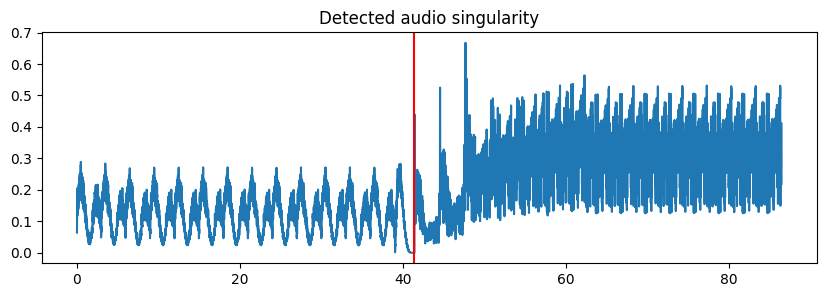

In [20]:


import soundfile as sf

audio, sr = sf.read("margento_#graphpoem_dhsi23_singularity_transition_19.wav")

# convert to mono if stereo
if audio.ndim > 1:
    audio = audio.mean(axis=1)

# energy envelope
window = int(sr * 0.02)  # 20 ms
env = np.sqrt(np.convolve(audio**2, np.ones(window)/window, mode='same'))

# detect shock (largest sudden rise)
diff = np.diff(env)
shock_index = np.argmax(diff)

shock_time = shock_index / sr
print("Shock time (seconds):", shock_time)

# visualize to confirm
t = np.arange(len(env))/sr
plt.figure(figsize=(10,3))
plt.plot(t, env)
plt.axvline(shock_time, color='red')
plt.title("Detected audio singularity")
plt.show()

In [21]:
N_FRAMES = 120

In [22]:

# PLACING THE SHOCK IN THE VIDEO THE SAME TIME AS THE AUDIO
shock_mid_frame = N_FRAMES * (shock_time-2) # shcok frame length, 2 sec

audio_duration = len(audio)/sr
print(audio_duration)

86.4


In [23]:
shock_time

41.39

In [403]:

def match_loudness(reference, target, target_level_db=-18):
    """
    Match perceived loudness of 'target' to 'reference'.
    Returns scaled target.
    """

    def rms(x):
        return np.sqrt(np.mean(x**2) + 1e-12)

    ref_rms = rms(reference)
    tgt_rms = rms(target)

    # desired scaling
    gain = ref_rms / tgt_rms

    # optional artistic offset (in dB)
    gain *= 10**(target_level_db/20)

    return target * gain

In [ ]:
!pip install pyloudnorm

In [ ]:

import soundfile as sf
import pyloudnorm as pyln

# 1. Load files
main, sr = sf.read('margento_#graphpoem_dhsi23_singularity_transition_19.wav')
overture, sr2 = sf.read('margento_#graphpoem_dhsi23_singularity_transition_2.wav')

# 2. Convert to mono if necessary (pyloudnorm expects [samples, channels])
if main.ndim > 1: main = main.mean(axis=1)
if overture.ndim > 1: overture = overture.mean(axis=1)

# 3. Measure integrated loudness (LUFS) for both
meter = pyln.Meter(sr) # Create BS.1770 meter
loudness_main = meter.integrated_loudness(main)
loudness_overture = meter.integrated_loudness(overture)

# 4. Match overture to main's loudness level
overture_balanced = pyln.normalize.loudness(overture, loudness_overture, loudness_main)

# 5. Save the result
sf.write('overture_matched.wav', overture_balanced, sr2)


In [420]:
audio_duration

86.4

In [17]:

def draw_paper_background(ax, width=900, height=900, seed=4):
    """
    Procedurally generates an old-paper texture behind the graph.
    No external images needed.
    """

    rng = np.random.default_rng(seed)

    # base paper tone
    base = np.array([0.94, 0.91, 0.83])   # warm aged paper RGB

    # large-scale fiber variation
    coarse = rng.normal(0, 0.015, (height//6, width//6))
    coarse = np.kron(coarse, np.ones((6,6)))[:height,:width]

    # fine grain
    fine = rng.normal(0, 0.006, (height, width))

    texture = coarse + fine

    # foxing spots (brown oxidation dots)
    spots = np.zeros((height, width))
    for _ in range(35):
        cx = rng.integers(0, width)
        cy = rng.integers(0, height)
        r = rng.integers(15, 70)

        y, x = np.ogrid[:height, :width]
        mask = (x-cx)**2 + (y-cy)**2 <= r*r
        spots[mask] += rng.uniform(0.04, 0.09)

    # edge darkening
    yy, xx = np.mgrid[0:height, 0:width]
    edge = ((xx-width/2)**2 + (yy-height/2)**2) / (width*height)
    edge = 0.22 * edge

    # combine layers
    paper = np.zeros((height, width, 3))
    for i in range(3):
        paper[:,:,i] = base[i] - texture - spots - edge

    paper = np.clip(paper, 0, 1)

    ax.imshow(
        paper,
        extent=[-1.5,1.5,-1.5,1.5],
        zorder=0,
        aspect='auto'
    )

In [18]:

def get_node_community(n, alpha):
    """
    Returns which community a node belongs to at this frame.
    PRE dominates early, POST dominates late.
    """
    if alpha < 0.5:
        if n in G_prev.nodes and "community" in G_prev.nodes[n]:
            return G_prev.nodes[n]["community"]
        elif n in G_post.nodes and "community" in G_post.nodes[n]:
            return G_post.nodes[n]["community"]
    else:
        if n in G_post.nodes and "community" in G_post.nodes[n]:
            return G_post.nodes[n]["community"]
        elif n in G_prev.nodes and "community" in G_prev.nodes[n]:
            return G_prev.nodes[n]["community"]

    return 0

In [25]:
len(G_prev.nodes)

42

In [424]:
len(G_post.nodes)

45

In [30]:

THAT_PRE = 19
THAT_POST = 13

# -----------------------------------
# settings
# -----------------------------------
FPS = 30

DURATION = audio_duration
N_FRAMES = int(FPS * DURATION)

FRAME_DIR = "frames"
# FRAME_DIR = "frames_1"
os.makedirs(FRAME_DIR, exist_ok=True)

label_jitter = 0.005          # smaller jitter for labels
label_size = 10               # larger font size

# -----------------------------------
# layouts (important: stable layout)
# -----------------------------------
pos_prev = nx.spring_layout(G_prev, seed=7, k=0.6, iterations=200)
pos_post = nx.spring_layout(G_post, seed=7, k=0.6, iterations=200)

# move THAT to center in both graphs
pos_prev[THAT_PRE] = np.array([0.0, 0.0])
pos_post[THAT_POST] = np.array([0.0, 0.0])

# -----------------------------------
# union sets
# -----------------------------------
all_nodes = set(G_prev.nodes) | set(G_post.nodes)
all_edges = set(G_prev.edges()) | set(G_post.edges())

# -----------------------------------
# poem fragments
# ---------------------------------
# -----------------------------
# NODE LABELS: multiple fragments for cycling
# -----------------------------
# pre_fragments and post_fragments should be lists of strings per node, e.g.
pre_fragments = {0: ["cursor","traffic", "antlers", "caru’ naval"], 1: ["poly(dis)tich", "range", "ashes", "touted"], 2:["rock ’n’ roll of alt, control","fall", "out of range"], 3: ["lines", "haptic","OS", "in sync"], \
                 4: ["phone","OM","caru’ naval"], 5: ["hot flows", "free", "to fall out"], 6: ["of range", "shaped by the dead", "standing in lines", "and romance"], \
                 7: ["an errant sort", "going here and there", "we owe to rust", "Awater"], 8: ["res ring of ashes", "in Faro", "on offer", "hews"], 9: ["heralds", "early keeper’s phone", "molded by", "Goldsmith"], \
                 10: ["OM", "Ur-dent", "abreast of", "soft orbs"], 11: ["Awater", "meth or", "valor", "you earth"], 12: ["OS’s", "oggled", "touted", "entrada"], 13: ["touted", "by mega-names", "les mega-noms", "a dance"], \
                 14: ["just the way", "one", "knows", "Noon"], 15: ["in life", "and so", "it goes", "OCRed"], 16: ["you earth", "me beings", "boding the truth", "hot flows"], 17: ["entrada", "caru’ naval", "in sync", "a Borges"], \
                 18: ["on ($)now", "with poly(dis)tich", "macho foes", "traffic"], 19: ["ham", "on ranches", "OCRed", "by Lupe Gomez"], 20: ["who’s", "hews", "of a Borges", "magi"], 21: ["nutcase", "wimpy bully", "ruling folly", "standing in lines"], \
                22: ["delight", "underrated", "with quills (kills?)", "we owe to rust"], 23: ["to urns", "a dance", "of antlers", "me beings"], 24: ["and romance", "home for", "magi", "Mandelstam"], \
                25: ["with soft orbs", "High", "in splendid", "traffic a[m]p(π)s"], 26: ["Rachel by", "Matthew Arnold", "OS’s", "Draft number"], 27: ["Meganom by", "Osip", "Mandelstam", "live"], \
                28: ["trans. Alistair", "Noon", "soft orbs", "meth"], 29: ["Secret Energy", "of orgasm", "by Lupe Gomez", "trans. Erin Moore"], 30: ["January 9", "1937", "by Osip", "concentration", "camp"], \
                31: ["Mandelstam trans", "John", "High", "interstate"], 32: ["Matvei", "Yankelevich", "of range", "shooting"], 33: ["France by", "Oliver", "Goldsmith", "going here and there"], 34: ["on offer", "one knows", "a dance", "res ring"], \
                34: ["abreast of", "macho foes", "shaped by the dead", "adrift"], 35: ["meth or", "urns", "quills (kills?)", "no...mad"], 36: ["res ring", "home", "in life", "be...long"], 37: ["you earth", "oggled", "romance", "main"], \
                38: ["going", "caru’", "Awater", "loco...motif"], 39: ["OCRed", "rock ’n’ roll", "knows", "the snows"], 40: ["of alt, control", "Noon", "les mega-noms", "no-home homme"], 41: ["me beings", "hot flows", "free", "for free"]}
 
post_fragments = {0: ["whirl", "breath", "rumps & ruins", "escala fosca"], 1: ["crow","smog","paths", "del desig"], 2: ["echo","blank moans", "roads to", "one tεxτ"], 3: ["the int/ εr®iOr", "fire", "shade", "no té baran"], 4: ["tides", "the sheen", "rumps & ruins", "about comp"], \
                  5: ["holo-hosomichi", "φRAGment", "misMAGne(τ)ment", "breath"], 6: ["about comp", "tinct", "the always hollow", "complet(h)eℕess"], 7: ["under", "moony money smog", "the glimmers", "of a sound polis"], \
                  8: ["our world", "planes of plains", "the river", "sp®eading wings"], 9: ["note", "drowning shade", "ex", "tinct"], 10: ["extinct", "already", "soon", "forever"], 11: ["rhyme", "read", "reach", "I'm time"], \
                  12: ["smothered thyme", "elm", "realm", "of writing"], 13: ["once", "never so", "ex", "tens(€)ive"], 14: ["one", "everybody", "pub", "£[EA]shes"], 15: ["pub£[EA]shes", "one tεxτ", "one sect", "a day"], \
                  16: ["fire", "in the mir[€]", "(OR)ror"], 17: ["the one", "returning", "all body", "now(/)here"], 18: ["and tides", "come and go like", "ghosts", "hosts"], 19: ["like poetry", "the ream", "stream", "lived up"], \
                  17: ["to its word", "obscured", "pebbles crystal clear", "glimmering"], 18: ["red gems", "if green", "brilliantly green", "red green"], 19: ["clean", "safe", " and all that sh...een", "siren$", "Φire"], \
                  20: ["stifled", "groan", "water rose", "mo(o/)ans"], 21: ["dangerous", "level", "revel", "like auras"], 22: ["of photo(ℕ)", "graphs", "photo(ℕ)graphs", "auto£αℝks"], 23: ["away", "by the way", "the byway", "I came"], \
                  24: ["info-whirls", "no words", "Gellu’s murmurs", "bandwidth stutter"], 25: ["blue lions’ sigh", "no water", "ℕ-awater", "in sight"], 26: ["jusque", "night", "de", "sãndzã"], 27: ["à vos reins", "à vos ruines", "breath", "mir[€](O®)ror"], \
                  28: ["on your rumps", "on your ruins", "to tell", "sapΠφΟ"], 29: ["no seeing", "what", "breath", "jestURe"], 30: ["stop", "can’t stop", "deep", "muffled gasps"], 31: ["blackness", "acheness", "lengthens", "mere thought"], \
                  32: ["tongue", "breaks", "sudden", "blood-rush"], 33: ["drums", "in ears", "steer", "green"], 34: ["green", "greener", "grass", "I am"], 35: ["the", "uncut hair", "of graves", "that place"], 36: ["you", "you WOmen", "I make", "my way"], \
                  37: ["$te(α)rn", "$τE(α)DDY", "a¢®id", "large"], 38: ["deceased whales", "floating above", "keeping", "silent"], 39: ["with a death tongue", "stymmied", "shimmying", "shortcut-overflow"], 40: ["shaking", "seeking", "trembling", "traffic"], \
                  41: ["hot", "dare not", "withdraw", "I deposit"], 42: ["what", "has", "accumulated", "in the bin"], 43: ["that place", "race", "blankness", "plenitude"], 44: ["unsortable", "useless", "refuse", "like a gOdd"]}


# Create cycles for each node
# pre_cycles = {n: cycle(frags) for n, frags in pre_fragments.items()}
# post_cycles = {n: cycle(frags) for n, frags in post_fragments.items()}

# Start with first item
# pre_labels = {n: next(c) for n, c in pre_cycles.items()}
# post_labels = {n: next(c) for n, c in post_cycles.items()}
# -----------------------------------
# diagram style colors
# -----------------------------------
# community_colors = {
    # 0: "#2b2b2b",
    # 1: "#6e6e6e",
    # 2: "#b0b0b0",
    # 3: "#d8d8d8"
#}


# EDGE_COLOR = "#9a9a9a"

# paper-friendly node tones
community_colors = {
    0: (0.55, 0.55, 0.55, 0.22),
    1: (0.60, 0.60, 0.60, 0.20),
    2: (0.65, 0.65, 0.65, 0.18),
    3: (0.70, 0.70, 0.70, 0.16)
}

EDGE_COLOR = (0.25, 0.25, 0.25, 0.18)

# -----------------------------------
# singularity timing
# -----------------------------------
shock_mid = int(shock_time * FPS)
shock_width = int(2 * FPS)  # collapse lasts 2 sec

shock_start = shock_mid - shock_width//2
shock_end   = shock_mid + shock_width//2

# -----------------------------
# FUNCTIONS
# -----------------------------
def scale_positions(pos, factor):
    """Scale all node positions by a factor from center (0,0)."""
    return {n: (x*factor, y*factor) for n, (x,y) in pos.items()}

def draw_graph(G, pos, comm_map, labels, jitter=0.005):
    """Draw a single frame of the graph with nodes, edges, and labels."""
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_facecolor('#f3f0e8')           # antique/patina background
    fig.patch.set_facecolor('#f3f0e8')
    ax.axis('off')

    # edges
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ax.plot([x0, x1], [y0, y1], color='gray', alpha=0.5, zorder=1)

    # nodes
    for n, (x, y) in pos.items():
        ax.scatter(
            x, y, s=200,
            color=community_colors[comm_map[n] % len(community_colors)],
            edgecolor='k', zorder=3
        )

    # labels
    for n, (x, y) in pos.items():
        plt.text(
            x + np.random.uniform(-jitter, jitter),
            y + np.random.uniform(-jitter, jitter),
            labels[n],
            fontsize=label_size,
            ha='center',
            va='center',
            zorder=4
        )

    return fig, ax

# -----------------------------
# PRECOMPUTE LAYOUTS
# -----------------------------
# PRE layout (stable world)   
pos_prev = nx.spring_layout(G_prev, seed=7, k=0.6, iterations=300)

# build an initial position dictionary for POST
pos_init_post = {}

for n in G_post.nodes():
    if n in pos_prev:
        pos_init_post[n] = pos_prev[n]          # same node continues
    else:
        pos_init_post[n] = np.random.normal(scale=0.02, size=2)  # new poem appears near center

# POST layout evolves FROM PRE physics
pos_post = nx.spring_layout(
    G_post,
    pos=pos_init_post,
    k=0.6,
    iterations=300
)

comm_prev = nx.get_node_attributes(G_prev, 'community')
comm_post = nx.get_node_attributes(G_post, 'community')

import random
from itertools import cycle

# build cycles per node
# pre_cycles  = {n: cycle(pre_fragments)  for n in G_prev.nodes}
# post_cycles = {n: cycle(post_fragments) for n in G_post.nodes}

# pre_labels  = {n: next(pre_cycles[n])  for n in G_prev.nodes}
# post_labels = {n: next(post_cycles[n]) for n in G_post.nodes}


# stores what each node is currently "saying"
node_text = {}

def get_node_text(node, phase):
    """
    Each node keeps a phrase for a while,
    then occasionally mutates into another phrase
    from its own fragment list.
    """

    if phase == "pre":
        frag_dict = pre_fragments
    else:
        frag_dict = post_fragments

    # node might not exist in that phase
    if node not in frag_dict:
        return ""

    # initialize memory
    if node not in node_text:
        node_text[node] = random.choice(frag_dict[node])

    # slow mutation (important!!)
    if random.random() < 0.06:   # ~ once every ~15 frames
        node_text[node] = random.choice(frag_dict[node])

    return node_text[node]


# -----------------------------------
# frame loop
# -----------------------------------

for i in range(N_FRAMES):

    alpha = i / (N_FRAMES - 1)

    # --------------------------------------------------
    # 1. INTERPOLATE POSITIONS (core physics)
    # --------------------------------------------------
    pos = {}

    for n in all_nodes:
        x0, y0 = pos_prev.get(n, (0,0))
        x1, y1 = pos_post.get(n, (x0,y0))

        pos[n] = (
            x0*(1-alpha) + x1*alpha,
            y0*(1-alpha) + y1*alpha
        )

    if alpha < 0.5:
        for n in G_post.nodes:
            if n not in G_prev.nodes:
                pos[n] = pos.get(THAT_PRE, (0,0))
    # --------------------------------------------------
    # 2. SINGULARITY COLLAPSE
    # --------------------------------------------------
    if shock_start <= i <= shock_end:

        collapse = 1 - abs((i - shock_mid)/((shock_end-shock_start)/2))
        
        center_node = THAT_PRE if alpha < 0.5 else THAT_POST
        cx, cy = pos.get(center_node, (0,0))

        for n in pos:
            x, y = pos[n]
            pos[n] = (
                x + (cx-x)*collapse*0.85,
                y + (cy-y)*collapse*0.85
            )

    # --------------------------------------------------
    # 3. POST EXPANSION (NEW — hurricane emergence)
    # --------------------------------------------------
    if i > shock_end:

        # gradual expansion after the event
        post_alpha = (i - shock_end) / (N_FRAMES - shock_end)
        post_alpha = np.clip(post_alpha, 0, 1)

        expansion = 1 + 1.8 * post_alpha  # <-- strength of hurricane

        for n in pos:
            x, y = pos[n]
            pos[n] = (x * expansion, y * expansion)

    # --------------------------------------------------
    # DRAW FRAMe
    # --------------------------------------------------
    # fig, ax = plt.subplots(figsize=(8,8), dpi=150)

    # Diagram patina background
    # ax.set_facecolor('#f3f0e8')
    # fig.patch.set_facecolor('#f3f0e8')

    # plt.axis('off')
    # plt.xlim(-2.2,2.2)
    # plt.ylim(-2.2,2.2)

    fig, ax = plt.subplots(figsize=(8,8), dpi=150)
    ax.axis('off')

    ax.set_xlim(-2.2,2.2)
    ax.set_ylim(-2.2,2.2)

    # Patina background
    draw_paper_background(ax)

    # softening the page edges
    ax.add_patch(plt.Rectangle(
        (-2.2,-2.2),
        4.4,
        4.4,
        linewidth=2.0,
        edgecolor=(0,0,0,0.15),
        facecolor='none',
        zorder=20
    ))
    # --------------------------------------------------
    # EDGES (interpolated topology)
    # --------------------------------------------------
    for u,v in all_edges:

        if u not in pos or v not in pos:
            continue

        weight_prev = 1 if G_prev.has_edge(u,v) else 0
        weight_post = 1 if G_post.has_edge(u,v) else 0

        weight = (1-alpha)*weight_prev + alpha*weight_post

        if weight > 0:
            # plt.plot(
                # [pos[u][0],pos[v][0]],
                # [pos[u][1],pos[v][1]],
                # color=EDGE_COLOR,
                # alpha=0.18*weight,
                # linewidth=0.6,
                # zorder=1
            #)
            plt.plot(
                [pos[u][0],pos[v][0]],
                [pos[u][1],pos[v][1]],
                color="#5c5a54",
                alpha=0.22*weight,
                linewidth=0.7,
                zorder=1
            )

    # --------------------------------------------------
    # NODES + TEXT
    # --------------------------------------------------
    for n, (x, y) in pos.items():

        # c = community_colors.get(comm_map.get(n, 0), (0.6,0.6,0.6,0.2))
        
        community = get_node_community(n, alpha)
        c = community_colors.get(community, (0.6, 0.6, 0.6, 0.2))

        # soft node body (faint graphite circle)
        ax.scatter(
            x, y,
            s=260,
            color=c,
            edgecolors=(0,0,0,0),
            zorder=2
        )

        # thin pencil outline (Diagram look)
        ax.scatter(
            x, y,
            s=260,
            facecolors='none',
            edgecolors=(0,0,0,0.25),
            linewidths=0.5,
            zorder=3
        )

        # ------------------------------------------
        # LABEL CYCLING
        # ------------------------------------------
        word = ""
        
        if not (shock_start <= i <= shock_end):

            # if i % 6 == 0:
                # if n in pre_labels:
                    # pre_labels[n] = next(pre_cycles[n])
                # if n in post_labels:
                    # post_labels[n] = next(post_cycles[n])

            if alpha < 0.5 and n in G_prev.nodes:
                word = get_node_text(n, "pre")

            elif alpha >= 0.5 and n in G_post.nodes:
                word = get_node_text(n, "post")

            if word:
                ax.text(
                    x + np.random.uniform(-0.01,0.01),
                    y + np.random.uniform(-0.01,0.01),
                    word,
                    fontsize=9,
                    ha='center',
                    va='center',
                    color="#1a1a1a",
                    zorder=10,
                    bbox=dict(
                        boxstyle="round,pad=0.12",
                        fc=(0.95,0.93,0.88,0.75),   # paper color halo
                        ec=(0,0,0,0)
                    )
                )

    # --------------------------------------------------
    # THE WORD "THAT" (singularity flash)
    # --------------------------------------------------
    if i == shock_mid:
        plt.text(
            0, 0, "THAT",
            fontsize=32,
            ha='center',
            va='center',
            color="black",
            zorder=10
        )

    # --------------------------------------------------
    # SAVE
    # --------------------------------------------------
    plt.savefig(
        f"{FRAME_DIR}/frame_{i:05d}.png",
        dpi=150,
        bbox_inches='tight',
        pad_inches=0
    )

    plt.close()


In [ ]:

ffmpeg -r 30 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p

# ffmpeg -r 30 -i frames_1/frame_%05d.png -c:v libx264 -pix_fmt yuv420p

In [ ]:
# OVERTURE

In [21]:



import soundfile as sf

audio, sr = sf.read("overture_matched.wav")

# convert to mono if stereo
if audio.ndim > 1:
    audio = audio.mean(axis=1)

# energy envelope
window = int(sr * 0.02)  # 20 ms
env = np.sqrt(np.convolve(audio**2, np.ones(window)/window, mode='same'))

# detect shock (largest sudden rise)
diff = np.diff(env)
shock_index_o = np.argmax(diff)

shock_time_o = shock_index_o / sr
print("Overture shock time (seconds):", shock_time_o)

# visualize to confirm
t = np.arange(len(env))/sr
plt.figure(figsize=(10,3))
plt.plot(t, env)
plt.axvline(shock_time_o, color='red')
plt.title("Detected audio singularity in the overture")
plt.show()

Overture shock time (seconds): 24.134625


AttributeError: module 'matplotlib' has no attribute 'figure'

In [21]:

import librosa

duration_o = librosa.get_duration(path='overture_matched.wav')
print(f"Duration: {duration_o:.2f} seconds")


Duration: 49.40 seconds


In [23]:
# duration_o = 49.40

In [24]:
import random

# IN CASE KERNEL HAS BEEN RESTARTED:

pre_fragments = {0: ["cursor","traffic", "antlers", "caru’ naval"], 1: ["poly(dis)tich", "range", "ashes", "touted"], 2:["rock ’n’ roll of alt, control","fall", "out of range"], 3: ["lines", "haptic","OS", "in sync"], \
                 4: ["phone","OM","caru’ naval"], 5: ["hot flows", "free", "to fall out"], 6: ["of range", "shaped by the dead", "standing in lines", "and romance"], \
                 7: ["an errant sort", "going here and there", "we owe to rust", "Awater"], 8: ["res ring of ashes", "in Faro", "on offer", "hews"], 9: ["heralds", "early keeper’s phone", "molded by", "Goldsmith"], \
                 10: ["OM", "Ur-dent", "abreast of", "soft orbs"], 11: ["Awater", "meth or", "valor", "you earth"], 12: ["OS’s", "oggled", "touted", "entrada"], 13: ["touted", "by mega-names", "les mega-noms", "a dance"], \
                 14: ["just the way", "one", "knows", "Noon"], 15: ["in life", "and so", "it goes", "OCRed"], 16: ["you earth", "me beings", "boding the truth", "hot flows"], 17: ["entrada", "caru’ naval", "in sync", "a Borges"], \
                 18: ["on ($)now", "with poly(dis)tich", "macho foes", "traffic"], 19: ["ham", "on ranches", "OCRed", "by Lupe Gomez"], 20: ["who’s", "hews", "of a Borges", "magi"], 21: ["nutcase", "wimpy bully", "ruling folly", "standing in lines"], \
                22: ["delight", "underrated", "with quills (kills?)", "we owe to rust"], 23: ["to urns", "a dance", "of antlers", "me beings"], 24: ["and romance", "home for", "magi", "Mandelstam"], \
                25: ["with soft orbs", "High", "in splendid", "traffic a[m]p(π)s"], 26: ["Rachel by", "Matthew Arnold", "OS’s", "Draft number"], 27: ["Meganom by", "Osip", "Mandelstam", "live"], \
                28: ["trans. Alistair", "Noon", "soft orbs", "meth"], 29: ["Secret Energy", "of orgasm", "by Lupe Gomez", "trans. Erin Moore"], 30: ["January 9", "1937", "by Osip", "concentration", "camp"], \
                31: ["Mandelstam trans", "John", "High", "interstate"], 32: ["Matvei", "Yankelevich", "of range", "shooting"], 33: ["France by", "Oliver", "Goldsmith", "going here and there"], 34: ["on offer", "one knows", "a dance", "res ring"], \
                34: ["abreast of", "macho foes", "shaped by the dead", "adrift"], 35: ["meth or", "urns", "quills (kills?)", "no...mad"], 36: ["res ring", "home", "in life", "be...long"], 37: ["you earth", "oggled", "romance", "main"], \
                38: ["going", "caru’", "Awater", "loco...motif"], 39: ["OCRed", "rock ’n’ roll", "knows", "the snows"], 40: ["of alt, control", "Noon", "les mega-noms", "no-home homme"], 41: ["me beings", "hot flows", "free", "for free"]}
 
post_fragments = {0: ["whirl", "breath", "rumps & ruins", "escala fosca"], 1: ["crow","smog","paths", "del desig"], 2: ["echo","blank moans", "roads to", "one tεxτ"], 3: ["the int/ εr®iOr", "fire", "shade", "no té baran"], 4: ["tides", "the sheen", "rumps & ruins", "about comp"], \
                  5: ["holo-hosomichi", "φRAGment", "misMAGne(τ)ment", "breath"], 6: ["about comp", "tinct", "the always hollow", "complet(h)eℕess"], 7: ["under", "moony money smog", "the glimmers", "of a sound polis"], \
                  8: ["our world", "planes of plains", "the river", "sp®eading wings"], 9: ["note", "drowning shade", "ex", "tinct"], 10: ["extinct", "already", "soon", "forever"], 11: ["rhyme", "read", "reach", "I'm time"], \
                  12: ["smothered thyme", "elm", "realm", "of writing"], 13: ["once", "never so", "ex", "tens(€)ive"], 14: ["one", "everybody", "pub", "£[EA]shes"], 15: ["pub£[EA]shes", "one tεxτ", "one sect", "a day"], \
                  16: ["fire", "in the mir[€]", "(OR)ror"], 17: ["the one", "returning", "all body", "now(/)here"], 18: ["and tides", "come and go like", "ghosts", "hosts"], 19: ["like poetry", "the ream", "stream", "lived up"], \
                  17: ["to its word", "obscured", "pebbles crystal clear", "glimmering"], 18: ["red gems", "if green", "brilliantly green", "red green"], 19: ["clean", "safe", " and all that sh...een", "siren$", "Φire"], \
                  20: ["stifled", "groan", "water rose", "mo(o/)ans"], 21: ["dangerous", "level", "revel", "like auras"], 22: ["of photo(ℕ)", "graphs", "photo(ℕ)graphs", "auto£αℝks"], 23: ["away", "by the way", "the byway", "I came"], \
                  24: ["info-whirls", "no words", "Gellu’s murmurs", "bandwidth stutter"], 25: ["blue lions’ sigh", "no water", "ℕ-awater", "in sight"], 26: ["jusque", "night", "de", "sãndzã"], 27: ["à vos reins", "à vos ruines", "breath", "mir[€](O®)ror"], \
                  28: ["on your rumps", "on your ruins", "to tell", "sapΠφΟ"], 29: ["no seeing", "what", "breath", "jestURe"], 30: ["stop", "can’t stop", "deep", "muffled gasps"], 31: ["blackness", "acheness", "lengthens", "mere thought"], \
                  32: ["tongue", "breaks", "sudden", "blood-rush"], 33: ["drums", "in ears", "steer", "green"], 34: ["green", "greener", "grass", "I am"], 35: ["the", "uncut hair", "of graves", "that place"], 36: ["you", "you WOmen", "I make", "my way"], \
                  37: ["$te(α)rn", "$τE(α)DDY", "a¢®id", "large"], 38: ["deceased whales", "floating above", "keeping", "silent"], 39: ["with a death tongue", "stymmied", "shimmying", "shortcut-overflow"], 40: ["shaking", "seeking", "trembling", "traffic"], \
                  41: ["hot", "dare not", "withdraw", "I deposit"], 42: ["what", "has", "accumulated", "in the bin"], 43: ["that place", "race", "blankness", "plenitude"], 44: ["unsortable", "useless", "refuse", "like a gOdd"]}


In [26]:

FPS = 30
DURATION = duration_o
N_FRAMES = int(FPS * DURATION)
OVERTURE_DIR = 'frames_o'

os.makedirs(OVERTURE_DIR, exist_ok=True)

shock_frame = int(shock_time_o * FPS)

# stable layout
pos_target = nx.spring_layout(G_prev, seed=7, k=0.6, iterations=200)

# random starting positions (the "dust")
rng = np.random.default_rng(4)
pos_start = {n: rng.uniform(-2.5, 2.5, size=2) for n in G_prev.nodes}


for i in range(N_FRAMES):

    t = i / (N_FRAMES - 1)

    fig, ax = plt.subplots(figsize=(8,8), dpi=150)
    ax.axis('off')
    draw_paper_background(ax)

    pos = {}

    # ---- nodes move toward existence ----
    for n in G_prev.nodes:
        x0, y0 = pos_start[n]
        x1, y1 = pos_target[n]

        # slow easing
        ease = t*t*(3 - 2*t)   # smoothstep easing

        pos[n] = (
            x0*(1-ease) + x1*ease,
            y0*(1-ease) + y1*ease
        )

    # -------------------------
    # PRE-ECHO DISTURBANCE (compute first)
    # -------------------------
    disturbance = 0
    if abs(i - shock_frame) < int(0.3 * FPS):
        d = 1 - abs(i - shock_frame) / (0.3 * FPS)
        disturbance = d*d

    # jitter positions
    if disturbance > 0:
        jitter = 0.15 * disturbance
        for n in pos:
            pos[n] = (
                pos[n][0] + rng.normal(0, jitter),
                pos[n][1] + rng.normal(0, jitter)
            )

    # ---- edges appear ----
    if t > 0.40:
        edge_alpha = np.clip((t - 0.45) / 0.55, 0, 1)
        if disturbance > 0:
            edge_alpha *= (1 - 0.85 * disturbance)

        for u, v in G_prev.edges():
            ax.plot(
                [pos[u][0], pos[v][0]],
                [pos[u][1], pos[v][1]],
                color="#8a8a8a",
                alpha=0.18 * edge_alpha,
                linewidth=0.6,
                zorder=1
            )


    # ---- nodes ----
    node_alpha = min(1, t*1.8)
    for n,(x,y) in pos.items():
        ax.scatter(
            x,y,
            s=70,
            color=(0.7,0.7,0.7,node_alpha*0.35),
            edgecolor=(0,0,0,node_alpha*0.25),
            linewidth=0.25,
            zorder=2
        )
    
    # ---- words appear last ----
    if t > 0.78 and disturbance < 0.6: # given the duration, the second condition is superfluous, but save it in case we decide to shorten overture
        # label_alpha = (t-0.7)/0.3
        label_alpha = np.clip((t - 0.7) / 0.3, 0, 1)
        for n,(x,y) in pos.items():
            word = random.choice(pre_fragments[n] + post_fragments[n])
            ax.text(
                x,y,word,
                fontsize=8,
                ha='center',
                va='center',
                color=(0,0,0,label_alpha),
                zorder=3
            )

    plt.xlim(-2.2,2.2)
    plt.ylim(-2.2,2.2)

    plt.savefig(f"{OVERTURE_DIR}/frame_{i:05d}.png")
    plt.close()

In [ ]:

# IN TERMINAL

ffmpeg -r 30 -i frames_o/frame_%05d.png -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" -c:v libx264 -pix_fmt yuv420p #graphpoem_dhsi23_overture_silent.mp4

ffmpeg -i #graphpoem_dhsi23_overture_silent.mp4 -i overture.wav -c:v copy -c:a aac graphpoem_dhsi23_overture.mp4


In [31]:


def make_credit_frames(text, n_frames, start_index=0):
    for i in range(n_frames):
        fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
        ax.axis("off")

        # same dusty paper
        draw_paper_background(ax)

        fade = i / (n_frames * 0.5)
        fade = min(1, fade)
        
        # centered text inside square
        ax.text(
            0, 0, text,
            ha="center",
            va="center",
            fontsize=28,
            color=(0,0,0,0.85 * fade),
            transform=ax.transData,
            zorder=5
        )

        plt.xlim(-2.2, 2.2)
        plt.ylim(-2.2, 2.2)

        plt.savefig(f"{CREDITS_DIR}/frame_{start_index+i:05d}.png")
        plt.close()

    return start_index + n_frames


In [28]:

title_frames   = int(2.6 * FPS)
tagline_frames = int(2.6 * FPS)
author_frames  = int(2.6 * FPS)

In [32]:

CREDITS_DIR = "frames_credits"
os.makedirs(CREDITS_DIR, exist_ok=True)

idx = 0

idx = make_credit_frames("AFTER 'THAT'", title_frames, idx)
idx = make_credit_frames("#GraphPoem @ DHSI 2023\n\nThe Community & Corpus Singularity", tagline_frames, idx)
idx = make_credit_frames("MARGENTO", author_frames, idx)


In [ ]:

# IN TERMINAL:
ffmpeg -r 30 -i frames_credits/frame_%05d.png -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" -c:v libx264 -pix_fmt yuv420p #graphpoem_dhsi23_singularity_credits.mp4

ffmpeg -f lavfi -i anullsrc=channel_layout=stereo:sample_rate=44100 \
-t 1 silence.wav

ffmpeg -i #graphpoem_dhsi23_credits.mp4 -i silence.wav \
-c:v copy -c:a aac #graphpoem_dhsi23_credits_1.mp4

ffmpeg -i #graphpoem_dhsi23_singularity_credits.mp4 -i silence.wav \
-c:v copy -c:a aac #graphpoem_dhsi23_credits.mp4

ffmpeg -f lavfi -i anullsrc=channel_layout=stereo:sample_rate=44100 \
-t 4 silence.wav

ffmpeg -i graphpoem_dhsi23_overture.mp4 -i silence.wav \
-c:v copy -c:a aac #graphpoem_dhsi23_singularity_overture.mp4

ffmpeg -f concat -safe 0 \
-i ./graphpoem_dhsi23_video_components.txt \
-c copy \
about_that_by_margento.mp4

# NOPE, WE NEED MAIN FADE-IN
ffmpeg -i #graphpoem_dhsi23_singularity_main.mp4 \
-vf "fade=t=in:st=0:d=2.6" \
-af "afade=t=in:st=0:d=2.6" \
-c:v libx264 -pix_fmt yuv420p -crf 18 \
#graphpoem_dhsi23_singularity_main_fadein.mp4

# AND NOW
ffmpeg -f concat -safe 0 \
-i ./graphpoem_dhsi23_overture_and_main_combined.txt \
-c copy \
#graphpoem_dhsi23_overture_and_main.mp4


ffmpeg -i #graphpoem_dhsi23_singularity_credits.mp4 \
-f lavfi -i anullsrc=channel_layout=stereo:sample_rate=44100 \
-shortest \
-c:v copy \
-c:a aac \
#graphpoem_dhsi23_credits_with_audio.mp4

ffmpeg -f concat -safe 0 \
-i ./graphpoem_dhsi23_video_components.txt \
-c copy \
about_that_by_margento.mp4


ffmpeg \
-i #graphpoem_dhsi23_credits_with_audio.mp4 \
-i #graphpoem_dhsi23_overture_and_main.mp4 \
-filter_complex "
[0:v][1:v]concat=n=2:v=1:a=0[v];
[1:a]anull[a]
" \
-map "[v]" -map "[a]" \
-c:v libx264 -pix_fmt yuv420p -crf 18 \
about_that_margento.mp4


ffmpeg \
-f lavfi -i color=c=black:s=1920x1080:r=30:d=1 \
-f lavfi -i anullsrc=r=48000:cl=stereo \
-i #graphpoem_dhsi23_singularity_credits.mp4 \
-shortest \
-map 2:v -map 1:a \
-c:v libx264 -pix_fmt yuv420p -r 30 \
-c:a aac -ar 48000 \
#graphpoem_dhsi23_w_audio_credits.mp4


ffmpeg -i #graphpoem_dhsi23_singularity_overture.mp4 \
-c:v libx264 -pix_fmt yuv420p -r 30 \
-c:a aac -ar 48000 \
#graphpoem_dhsi23_singularity_overture_norm.mp4


ffmpeg -i #graphpoem_dhsi23_singularity_main_fadein.mp4 \
-c:v libx264 -pix_fmt yuv420p -r 30 \
-c:a aac -ar 48000 \
#about_that_by_margento.mp4


ffmpeg \
-i #graphpoem_dhsi23_w_audio_credits.mp4 \
-i #graphpoem_dhsi23_singularity_overture_norm.mp4 \
-i #about_that_by_margento.mp4
-filter_complex "[0:v:0][0:a:0][1:v:0][1:a:0][2:v:0][2:a:0]concat=n=3:v=1:a=1[v][a]" \
-map "[v]" -map "[a]" \
-c:v libx264 -pix_fmt yuv420p -crf 18 \
-c:a aac -ar 48000 \
about_that_margento.mp4


ffmpeg \
-i #graphpoem_dhsi23_w_audio_credits.mp4 \
-i #graphpoem_dhsi23_singularity_overture_norm.mp4 \
-i #about_that_by_margento.mp4 \
-filter_complex "[0:v:0][0:a:0][1:v:0][1:a:0][2:v:0][2:a:0]concat=n=3:v=1:a=1[v][a]" \
-map "[v]" -map "[a]" \
-c:v libx264 -pix_fmt yuv420p -crf 18 \
-c:a aac -ar 48000 \
about_that_margento.mp4


ffmpeg -i #graphpoem_dhsi23_w_audio_credits.mp4 \
-vf "scale=1200:1200:force_original_aspect_ratio=decrease,pad=1200:1200:(ow-iw)/2:(oh-ih)/2" \
-c:v libx264 -pix_fmt yuv420p -r 30 \
-c:a aac -ar 48000 \
#graphpoem_dhsi23_credits_norm.mp4

ffmpeg -i #graphpoem_dhsi23_singularity_overture.mp4 \
-vf "scale=1200:1200:force_original_aspect_ratio=decrease,pad=1200:1200:(ow-iw)/2:(oh-ih)/2" \
-c:v libx264 -pix_fmt yuv420p -r 30 \
-c:a aac -ar 48000 \
#graphpoem_dhsi23_singularity_overture_norm.mp4

ffmpeg -i #graphpoem_dhsi23_singularity_main_fadein.mp4 \
-vf "scale=1200:1200:force_original_aspect_ratio=decrease,pad=1200:1200:(ow-iw)/2:(oh-ih)/2" \
-c:v libx264 -pix_fmt yuv420p -r 30 \
-c:a aac -ar 48000 \
#about_that_by_margento.mp4

ffprobe #graphpoem_dhsi23_credits_norm.mp4 | grep 1200
ffprobe #graphpoem_dhsi23_singularity_overture_norm.mp4 | grep 1200
ffprobe #about_that_by_margento.mp4 | grep 1200


Margento@mac-ME22-119 ~ % ffmpeg \
-i "#graphpoem_dhsi23_credits_norm.mp4" \
-i "#graphpoem_dhsi23_singularity_overture_norm.mp4" \
-i "#about_that_by_margento.mp4" \
-filter_complex "\
[0:v]setsar=1[v0]; \
[1:v]setsar=1[v1]; \
[2:v]setsar=1[v2]; \
[v0][0:a][v1][1:a][v2][2:a]concat=n=3:v=1:a=1[v][a]" \
-map "[v]" -map "[a]" \
-c:v libx264 -pix_fmt yuv420p -crf 18 \
-c:a aac -ar 48000 \
about_that_margento.mp4
